In [10]:
import os
if os.getcwd()[-11:] == "exploration":
    os.chdir('..')
import data.involcan.pull

### Find sensors of interest

In [11]:
import pandas as pd

files = pd.read_csv("data/involcan/metadata/available_files.csv")

In [12]:
# from datetime import datetime
starttime = pd.Timestamp('2021-09-12', tz='UTC')
endtime = pd.Timestamp('2021-09-26', tz='UTC')

files['start_time'] = pd.to_datetime(files['start_time'], utc=True)
files['end_time'] = pd.to_datetime(files['end_time'], utc=True)


eruption_files = files[(files['start_time']==starttime) | (files['end_time']==endtime) ]
eruption_sensors = pd.unique(eruption_files['sensor'])

In [13]:
print(f"There were {len(eruption_sensors)} measuring during the eruption")
print(f"They were: \n {eruption_sensors}")

There were 18 measuring during the eruption
They were: 
 ['PGAR' 'PBBA' 'PPMA' 'PMLU' 'PLPI' 'PTAB' 'PCOR' 'PA03' 'PA00' 'PA05'
 'PA09' 'PA01' 'PA04' 'PA02' 'PA08' 'PA06' 'PA07' 'PSAB']


In [14]:
sensors = pd.read_csv("data/involcan/metadata/stations_all.dat", sep=r"\s+",names=["station", "lat", "lon", "height"])
sensors_lp = sensors[
    ((sensors['lat']<28.871164) & (sensors['lat']>28.437932)) &
    ((sensors['lon']<-17.666590) & (sensors['lon']>-18.039439))
]


### Download the files of interest

In [15]:
from datetime import datetime, timedelta
starttime = datetime(2021, 9, 14)
endtime = datetime(2021, 9, 26)
data_path = "/SCRATCH/TIC270/gsus/data/involcan/mseed/"
channels = ["HHE", "HHN", "HHZ"]
sensors = eruption_sensors

# data.involcan.pull.download_files(starttime, endtime, sensors, channels, data_path, user='seiscomp', verbose=True);

### Analyze the data

Reading 2021 data for sensor PPMA...


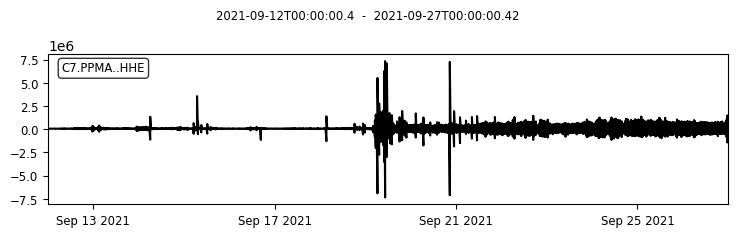

In [24]:
import obspy
sensor_id = 2
print(f"Reading 2021 data for sensor {eruption_sensors[sensor_id]}...")
st = obspy.read(f"{data_path}/C7.{eruption_sensors[sensor_id]}.*.2021.*")
st.merge()
st.plot();


#### Analyze frequencies with MESA

In [25]:
from msa.feature_extraction import features
from msa.visualization import plot

In [26]:
sr = st[0].stats.sampling_rate
signal = st[0].data
# time = st[0].times()


window_length = 4 # s
window_samples = int(window_length*sr)
shift = window_length*1000 #s
hop = int(shift*sr)
times, freq, Sxx = features.spectrogram(signal, sr, window_samples, hop, "blackman", "zeros", "linear")

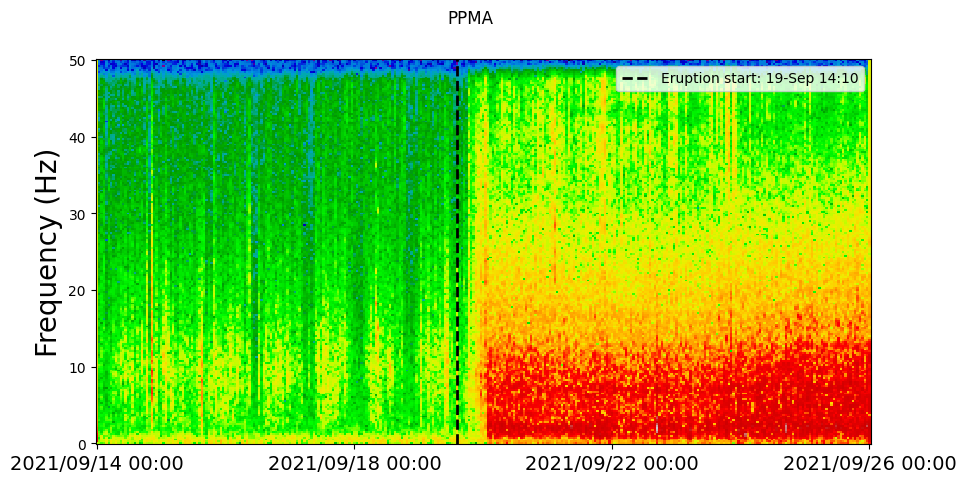

In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

timeUTC = np.linspace(starttime, endtime, num= len(times), dtype='datetime64[h]').astype("datetime64[m]")
target_time = np.datetime64(datetime(2021, 9, 19, 14, 10), 'm')

eruption_idx = np.argmin(np.abs(timeUTC - target_time))

fig, ax = plt.subplots(1,1, figsize=(10,5))
fig.suptitle(f"{eruption_sensors[sensor_id]}")
plot.spectrogram(times, freq, Sxx, cmap="nipy_spectral", logscale=True, ax = ax);

aux = mdates.date2num(timeUTC)
skip:int = len(times)//3
locs = times[0::skip]
timeUTC = timeUTC[0::skip]
date_formatter = mdates.DateFormatter('%Y/%m/%d %H:%M')
formatted_labels = [date_formatter(mdates.date2num(t)) for t in timeUTC]
ax.set_xticks(locs[:], labels=formatted_labels[:],fontsize=14);
ax.set_ylabel("Frequency (Hz)", fontsize=20)

ax.axvline(x=times[eruption_idx], color='black', linestyle='--', linewidth=2, label='Eruption start: 19-Sep 14:10')
ax.legend()

### PCA Visualizations

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Residual Variance Curve and CKF Curve'}, xlabel='Number of Principal Components', ylabel='Residual Variance'>)

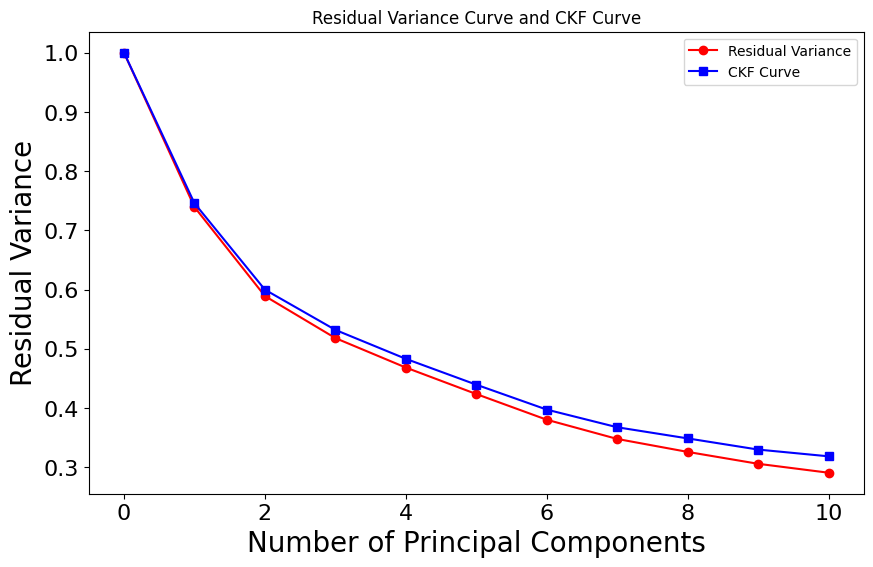

In [28]:
import mspc_pca.plot
data = Sxx.T
mspc_pca.plot.var_pca(data, 10)

In [29]:
# !pip install scikit-learn

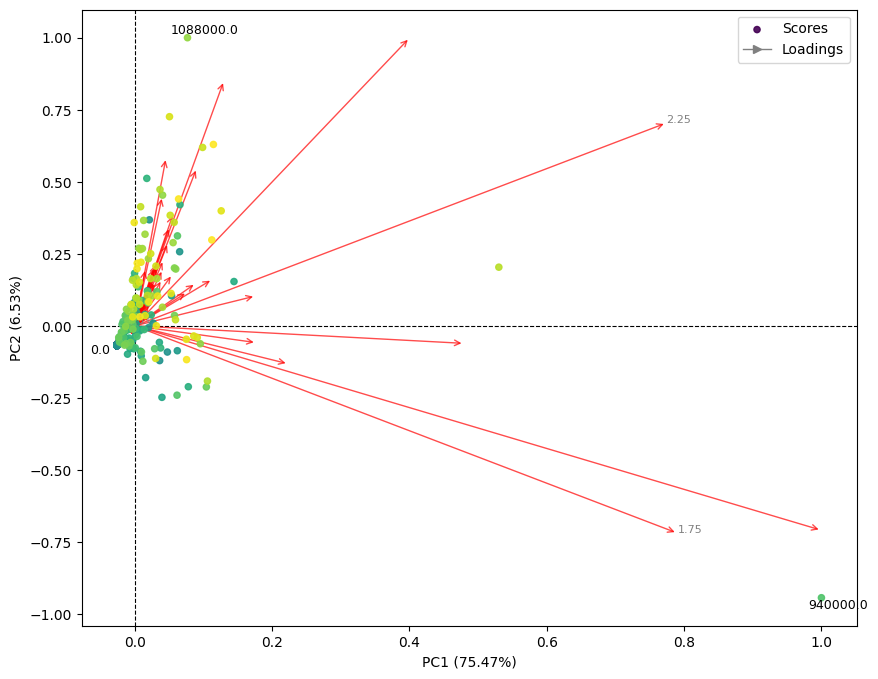

In [30]:


from sklearn.decomposition import PCA
pca = PCA(n_components=2)

mspc_pca.plot.biplot(data, pca, 1, 2, times, np.round(freq, 2), score_classes=times);

In [31]:
data.shape
rows = data.shape[0]

(<Figure size 1200x800 with 2 Axes>,
 [<Axes: title={'center': 'D-statistic'}, ylabel='D'>,
  <Axes: title={'center': 'Q-statistic'}, ylabel='Q'>])

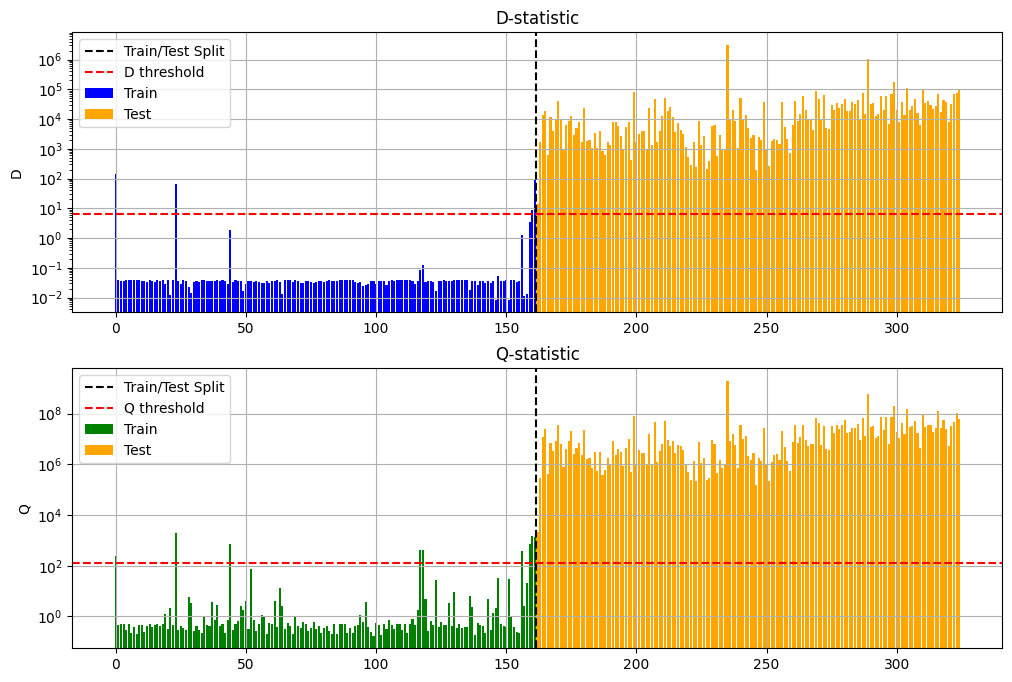

In [32]:
import mspc_pca.mspc
D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q = mspc_pca.mspc.DQ_tt(data[:rows//2], data[rows//2:], 2)

mspc_pca.mspc.plot_DQ_tt(D_train, Q_train, D_test, Q_test, threshold_D, threshold_Q, 
                alpha=None, type_q='Jackson', logscale=True, event_index=None, 
                labels=None, plot_train=True, opacity=None, ax=None)